In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "shelby_county_opportunity_data.csv"
)

df = pd.read_csv(
    DATA_FILE,
    dtype={
        "state": str,
        "county": str,
        "tract": str,
        "tract_geoid": str,
    },
)

df.head()


,geography_name,total_population,median_age,median_household_income,poverty_universe,population_below_poverty,civilian_labor_force,unemployed_population,occupied_housing_units,owner_occupied_units,...,median_gross_rent,median_home_value,state,county,tract,poverty_rate,unemployment_rate,homeownership_rate,rent_to_income_ratio,tract_geoid
0,Census Tract 1; Shelby County; Tennessee,5420.0,32.5,65236.0,5307.0,680.0,3499.0,103.0,3435.0,1172.0,...,1713.0,440400.0,47,157,000100,12.81,2.94,34.12,0.315,47157000100
1,Census Tract 2; Shelby County; Tennessee,1100.0,29.6,23231.0,1073.0,522.0,404.0,127.0,493.0,47.0,...,979.0,NaN,47,157,000200,48.65,31.44,9.53,0.506,47157000200
2,Census Tract 3; Shelby County; Tennessee,535.0,35.9,31146.0,535.0,137.0,196.0,16.0,243.0,154.0,...,1164.0,75000.0,47,157,000300,25.61,8.16,63.37,0.448,47157000300
3,Census Tract 4; Shelby County; Tennessee,1359.0,34.6,23370.0,1359.0,626.0,608.0,35.0,544.0,119.0,...,991.0,50800.0,47,157,000400,46.06,5.76,21.88,0.509,47157000400
4,Census Tract 6; Shelby County; Tennessee,1578.0,52.5,36696.0,1578.0,663.0,658.0,63.0,753.0,354.0,...,910.0,37500.0,47,157,000600,42.02,9.57,47.01,0.298,47157000600


In [3]:
df.shape

(249, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   geography_name            249 non-null    object 
 1   total_population          249 non-null    float64
 2   median_age                245 non-null    float64
 3   median_household_income   243 non-null    float64
 4   poverty_universe          249 non-null    float64
 5   population_below_poverty  249 non-null    float64
 6   civilian_labor_force      249 non-null    float64
 7   unemployed_population     249 non-null    float64
 8   occupied_housing_units    249 non-null    float64
 9   owner_occupied_units      249 non-null    float64
 10  renter_occupied_units     249 non-null    float64
 11  median_gross_rent         237 non-null    float64
 12  median_home_value         231 non-null    float64
 13  state                     249 non-null    object 
 14  county    

In [5]:
df.isna().sum().sort_values(ascending=False)

median_home_value           18
median_gross_rent           12
rent_to_income_ratio        12
poverty_rate                 6
median_household_income      6
homeownership_rate           6
unemployment_rate            6
median_age                   4
geography_name               0
poverty_universe             0
total_population             0
population_below_poverty     0
civilian_labor_force         0
owner_occupied_units         0
renter_occupied_units        0
unemployed_population        0
occupied_housing_units       0
tract                        0
county                       0
state                        0
tract_geoid                  0
dtype: int64

In [6]:
df.describe()

,total_population,median_age,median_household_income,poverty_universe,population_below_poverty,civilian_labor_force,unemployed_population,occupied_housing_units,owner_occupied_units,renter_occupied_units,median_gross_rent,median_home_value,poverty_rate,unemployment_rate,homeownership_rate,rent_to_income_ratio
count,249.000000,245.000000,243.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,237.000000,231.000000,243.000000,243.000000,243.000000,237.000000
mean,3691.457831,36.969388,67675.378601,3626.196787,646.321285,1844.863454,132.875502,1456.791165,788.670683,668.120482,1332.421941,223394.372294,20.880412,8.640082,51.411070,0.293397
std,1799.302067,7.448826,41050.228285,1818.204497,547.365768,1013.467935,114.448663,670.690482,554.550505,448.208488,406.323543,152521.266125,16.189972,7.519383,24.737017,0.109821
min,0.000000,20.100000,12132.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,616.000000,37500.000000,0.000000,0.000000,0.000000,0.083000
25%,2251.000000,31.400000,38112.000000,2234.000000,237.000000,1046.000000,52.000000,971.000000,358.000000,339.000000,1042.000000,96000.000000,6.815000,3.165000,34.160000,0.218000
50%,3559.000000,36.900000,55694.000000,3467.000000,538.000000,1838.000000,105.000000,1440.000000,732.000000,612.000000,1221.000000,174300.000000,18.470000,6.430000,49.450000,0.276000
75%,4920.000000,42.200000,88465.000000,4746.000000,865.000000,2468.000000,187.000000,1878.000000,1144.000000,930.000000,1585.000000,302150.000000,31.810000,11.805000,69.895000,0.345000
max,8927.000000,59.000000,236189.000000,8906.000000,3364.000000,5556.000000,592.000000,3435.000000,2612.000000,2379.000000,2705.000000,752500.000000,83.630000,43.780000,100.000000,0.743000


In [10]:
#Create readable burden percentage
df["rent_to_income_percent"] = (
    df["rent_to_income_ratio"] * 100
).round(1)

In [11]:
df[
    [
        "geography_name",
        "median_household_income",
        "median_gross_rent",
        "rent_to_income_percent",
    ]
].head()

,geography_name,median_household_income,median_gross_rent,rent_to_income_percent
0,Census Tract 1; Shelby County; Tennessee,65236.0,1713.0,31.5
1,Census Tract 2; Shelby County; Tennessee,23231.0,979.0,50.6
2,Census Tract 3; Shelby County; Tennessee,31146.0,1164.0,44.8
3,Census Tract 4; Shelby County; Tennessee,23370.0,991.0,50.9
4,Census Tract 6; Shelby County; Tennessee,36696.0,910.0,29.8


In [12]:
#Create analysis subset
analysis_df = df[
    df["total_population"] >= 500
].copy()

analysis_df.shape

(245, 22)

In [13]:
#Find the 10 highest income tracts
highest_income = (
    analysis_df[
        [
            "tract_geoid",
            "geography_name",
            "total_population",
            "median_household_income",
        ]
    ]
    .dropna(subset=["median_household_income"])
    .sort_values(
        "median_household_income",
        ascending=False,
    )
    .head(10)
)

highest_income

,tract_geoid,geography_name,total_population,median_household_income
186,47157021356,Census Tract 213.56; Shelby County; Tennessee,3439.0,236189.0
187,47157021357,Census Tract 213.57; Shelby County; Tennessee,5837.0,219722.0
193,47157021542,Census Tract 215.42; Shelby County; Tennessee,5812.0,217500.0
191,47157021530,Census Tract 215.30; Shelby County; Tennessee,5439.0,188750.0
68,47157008500,Census Tract 85; Shelby County; Tennessee,4143.0,182250.0
194,47157021543,Census Tract 215.43; Shelby County; Tennessee,3648.0,173135.0
80,47157009600,Census Tract 96; Shelby County; Tennessee,4759.0,169847.0
192,47157021541,Census Tract 215.41; Shelby County; Tennessee,7983.0,166356.0
175,47157021311,Census Tract 213.11; Shelby County; Tennessee,4409.0,160278.0
168,47157021139,Census Tract 211.39; Shelby County; Tennessee,4369.0,159886.0


In [14]:
#Find the 10 lowest income tracts
lowest_income = (
    analysis_df[
        [
            "tract_geoid",
            "geography_name",
            "total_population",
            "median_household_income",
        ]
    ]
    .dropna(subset=["median_household_income"])
    .sort_values("median_household_income")
    .head(10)
)

lowest_income

,tract_geoid,geography_name,total_population,median_household_income
38,47157005000,Census Tract 50; Shelby County; Tennessee,968.0,12132.0
44,47157005900,Census Tract 59; Shelby County; Tennessee,2082.0,14982.0
31,47157003700,Census Tract 37; Shelby County; Tennessee,1282.0,17266.0
43,47157005800,Census Tract 58; Shelby County; Tennessee,1096.0,17344.0
109,47157011600,Census Tract 116; Shelby County; Tennessee,2071.0,18182.0
33,47157003900,Census Tract 39; Shelby County; Tennessee,1384.0,19139.0
32,47157003800,Census Tract 38; Shelby County; Tennessee,699.0,20560.0
84,47157009902,Census Tract 99.02; Shelby County; Tennessee,2030.0,20563.0
1,47157000200,Census Tract 2; Shelby County; Tennessee,1100.0,23231.0
3,47157000400,Census Tract 4; Shelby County; Tennessee,1359.0,23370.0


In [15]:
#Highest Poverty tracts
highest_poverty = (
    analysis_df[
        [
            "tract_geoid",
            "geography_name",
            "total_population",
            "median_household_income",
            "poverty_rate",
        ]
    ]
    .sort_values(
        "poverty_rate",
        ascending=False,
    )
    .head(10)
)

highest_poverty

,tract_geoid,geography_name,total_population,median_household_income,poverty_rate
44,47157005900,Census Tract 59; Shelby County; Tennessee,2082.0,14982.0,83.63
38,47157005000,Census Tract 50; Shelby County; Tennessee,968.0,12132.0,73.86
43,47157005800,Census Tract 58; Shelby County; Tennessee,1096.0,17344.0,66.36
87,47157010120,Census Tract 101.20; Shelby County; Tennessee,5214.0,26112.0,64.52
109,47157011600,Census Tract 116; Shelby County; Tennessee,2071.0,18182.0,61.78
15,47157001900,Census Tract 19; Shelby County; Tennessee,1263.0,29653.0,60.89
89,47157010122,Census Tract 101.22; Shelby County; Tennessee,3315.0,25123.0,57.80
226,47157022025,Census Tract 220.25; Shelby County; Tennessee,3723.0,32558.0,57.37
232,47157022131,Census Tract 221.31; Shelby County; Tennessee,2197.0,32083.0,53.66
36,47157004500,Census Tract 45; Shelby County; Tennessee,673.0,30417.0,52.45


In [16]:
#Highest unemployment tracts
highest_unemployment = (
    analysis_df[
        [
            "tract_geoid",
            "geography_name",
            "total_population",
            "unemployment_rate",
            "poverty_rate",
        ]
    ]
    .sort_values(
        "unemployment_rate",
        ascending=False,
    )
    .head(10)
)

highest_unemployment

,tract_geoid,geography_name,total_population,unemployment_rate,poverty_rate
44,47157005900,Census Tract 59; Shelby County; Tennessee,2082.0,43.78,83.63
43,47157005800,Census Tract 58; Shelby County; Tennessee,1096.0,43.35,66.36
108,47157011500,Census Tract 115; Shelby County; Tennessee,1925.0,38.64,45.24
1,47157000200,Census Tract 2; Shelby County; Tennessee,1100.0,31.44,48.65
235,47157022220,Census Tract 222.20; Shelby County; Tennessee,3845.0,26.99,39.74
5,47157000700,Census Tract 7; Shelby County; Tennessee,3702.0,26.80,32.13
88,47157010121,Census Tract 101.21; Shelby County; Tennessee,2443.0,26.58,43.47
109,47157011600,Census Tract 116; Shelby County; Tennessee,2071.0,25.32,61.78
38,47157005000,Census Tract 50; Shelby County; Tennessee,968.0,25.09,73.86
232,47157022131,Census Tract 221.31; Shelby County; Tennessee,2197.0,25.00,53.66


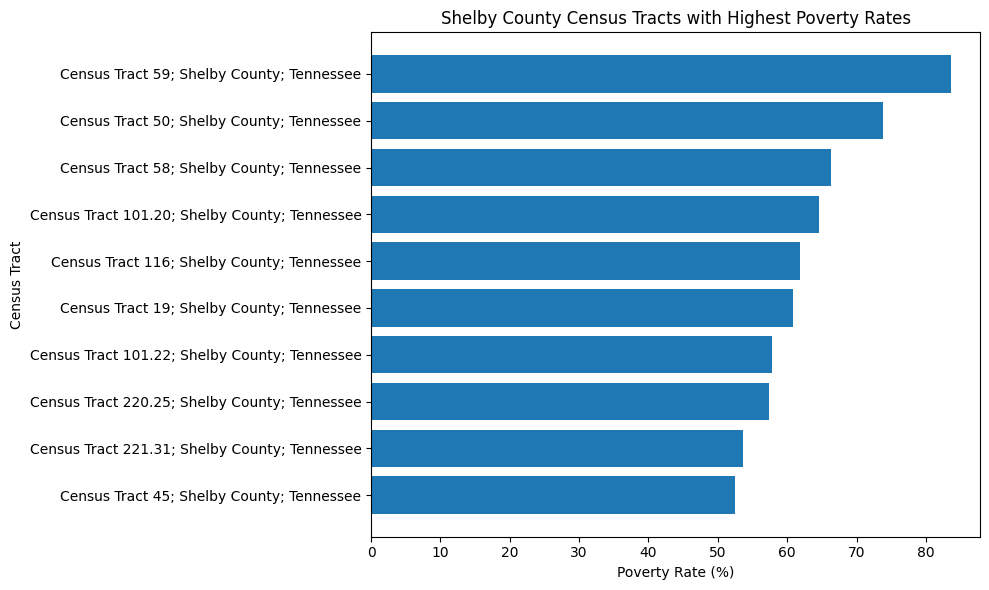

In [17]:
#Make first chart
top_poverty = (
    analysis_df
    .nlargest(10, "poverty_rate")
    .sort_values("poverty_rate")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_poverty["geography_name"],
    top_poverty["poverty_rate"],
)

plt.xlabel("Poverty Rate (%)")
plt.ylabel("Census Tract")
plt.title(
    "Shelby County Census Tracts with Highest Poverty Rates"
)

plt.tight_layout()
plt.show()